# Kako vpliva povprečna bruto plača na rodnost po regijah v Sloveniji?

In [1]:
import pandas as pd
import plotly.graph_objects as go
from scipy import stats
import plotly.io as pio
import json
import urllib.request

COLORS = {
    "muted_olive":   "#8CB369",
    "sandy_brown":   "#F4A259",
    "blushed_brick": "#BC4B51",
}

df = pd.read_csv('data/raw/csv/regije_avg_placa.csv', encoding='cp1250', sep=';', skiprows=2, decimal='.')
df.columns = ["regija", "bruto_2023", "bruto_2024", "bruto_2025", "neto_2023", "neto_2024", "neto_2025"]

rod = pd.read_csv('data/raw/csv/regije_rodnost.csv', encoding='cp1250', sep=';', skiprows=2)
rod.columns = ["leto", "regija", "skupaj", "na1000"]
rod["leto"] = rod["leto"].astype(int)

exclude = ["SLOVENIJA", "Vzhodna Slovenija", "Zahodna Slovenija"]
SLO_BRUTO = {2023: 2254.86, 2024: 2394.92, 2025: 2536.03}

rod_2024 = rod[rod["leto"] == 2024][["regija", "na1000"]].rename(columns={"na1000": "rodnost_2024"})

df_merge = (
    df[~df["regija"].isin(exclude)]
    .merge(rod_2024, on="regija")
    .sort_values("bruto_2023", ascending=True)
    .reset_index(drop=True)
)

V spodnji analizi raziskujemo povezanost med ekonomsko blaginjo, merjeno s povprečno bruto plačo (2023), in demografskimi trendi, natančneje rodnostjo (2024), po slovenskih statističnih regijah. Cilj je ugotoviti, ali višji prihodki v regiji delujejo kot spodbuden dejavnik za večje število rojstev na 1.000 prebivalcev.

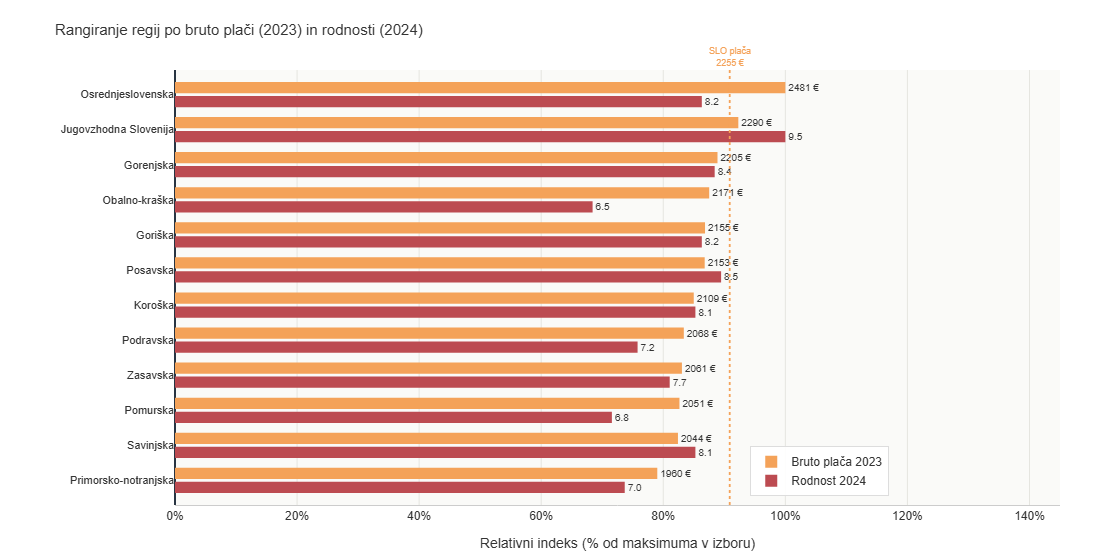

In [2]:
df_plot = df_merge.sort_values('bruto_2023', ascending=True).reset_index(drop=True)

df_plot['placa_idx'] = df_plot['bruto_2023']   / df_plot['bruto_2023'].max()   * 100
df_plot['rod_idx']   = df_plot['rodnost_2024'] / df_plot['rodnost_2024'].max() * 100

n       = len(df_plot)
y_placa = [i * 2.5 + 1.0 for i in range(n)]
y_rod   = [i * 2.5 + 0.0 for i in range(n)]
y_ticks = [i * 2.5 + 0.5 for i in range(n)]

fig = go.Figure()

fig.add_trace(go.Bar(
    x=df_plot['placa_idx'], y=y_placa,
    orientation='h',
    marker_color=COLORS['sandy_brown'], marker_line_width=0,
    name='Bruto plača 2023',
    text=[f'{v:.0f} €' for v in df_plot['bruto_2023']],
    textposition='outside', textfont=dict(size=10, color='#333333'),
    width=0.8,
    customdata=df_plot['bruto_2023'],
    hovertemplate='<b>%{y}</b><br>Bruto plača: %{customdata:.0f} €<extra></extra>'
))

fig.add_trace(go.Bar(
    x=df_plot['rod_idx'], y=y_rod,
    orientation='h',
    marker_color=COLORS['blushed_brick'], marker_line_width=0,
    name='Rodnost 2024',
    text=[f'{v:.1f}' for v in df_plot['rodnost_2024']],
    textposition='outside', textfont=dict(size=10, color='#333333'),
    width=0.8,
    customdata=df_plot['rodnost_2024'],
    hovertemplate='<b>%{y}</b><br>Rodnost: %{customdata:.1f} ‰<extra></extra>'
))

slo_placa_idx = SLO_BRUTO[2023] / df_plot['bruto_2023'].max() * 100
fig.add_vline(
    x=slo_placa_idx, line_dash='dot',
    line_color=COLORS['sandy_brown'], line_width=1.8,
    annotation_text=f'SLO plača<br>{SLO_BRUTO[2023]:.0f} €',
    annotation_position='top',
    annotation_font=dict(color=COLORS['sandy_brown'], size=9)
)

fig.update_layout(
    title='Rangiranje regij po bruto plači (2023) in rodnosti (2024)',
    barmode='overlay',
    width=1100, height=560,
    plot_bgcolor='#FAFAF8', paper_bgcolor='white',
    font=dict(family='Arial, sans-serif', size=12, color='#333333'),
    title_font=dict(size=15, color='#333333'),
    xaxis=dict(
        title='Relativni indeks (% od maksimuma v izboru)',
        range=[0, 145], ticksuffix='%',
        gridcolor='#E5E5E0', showline=True, linecolor='#CCCCCC',
        tickfont=dict(color='#333333')
    ),
    yaxis=dict(
        tickvals=y_ticks,
        ticktext=df_plot['regija'].tolist(),
        tickfont=dict(size=11, color='#333333'),
        showgrid=False
    ),
    legend=dict(
        x=0.65, y=0.02,
        bgcolor='rgba(255,255,255,0.9)',
        bordercolor='#DDDDDD', borderwidth=1,
        font=dict(color='#333333')
    ),
    margin=dict(l=175, r=40, t=70, b=55),
)

pio.renderers.default = 'png'
fig.show()

Vizualno lahko opazimo, da regije z višjimi plačami (npr. Jugovzhodna Slovenija in Osrednjeslovenska) pogosto izkazujejo tudi višje stopnje rodnosti, medtem ko imajo regije na dnu plačilne lestvice (npr. Pomurska, Obalno-kraška) rodnost pod povprečjem.

Omejitev podatkov: Analiza se osredotoča na primerjavo med letoma 2023 in 2024, saj so bili podatki za bruto plače na voljo za obdobje 2023-2025, medtem ko so se uradni podatki o rodnosti v času analize zaključili z letom 2024. Zaradi tega smo korelativni vpliv lahko preverili le za omenjeni presek let, kjer so podatki za obe spremenljivki popolni.

Za objektivno oceno povezanosti smo izračunali Pearsonov in Spearmanov koeficient korelacije:

In [3]:
r, p = stats.pearsonr(df_merge["bruto_2023"], df_merge["rodnost_2024"])
r_sp, p_sp = stats.spearmanr(df_merge["bruto_2023"], df_merge["rodnost_2024"])

smer = "pozitivna" if r > 0 else "negativna"
moc = "šibka" if abs(r) < 0.3 else "zmerna" if abs(r) < 0.6 else "močna"
sig = "statistično značilna (p < 0,05)" if p < 0.05 else "ni statistično značilna (p ≥ 0,05)"

print(f"Pearsonov r  = {r:.3f}   (p = {p:.3f})")
print(f"Spearmanov ρ = {r_sp:.3f}   (p = {p_sp:.3f})")
print()
print(f"Med povprečno bruto plačo regij (2023) in rodnostjo (2024) obstaja")
print(f"{moc} {smer} korelacija (r = {r:.3f}), ki {sig}.")

Pearsonov r  = 0.507   (p = 0.092)
Spearmanov ρ = 0.575   (p = 0.050)

Med povprečno bruto plačo regij (2023) in rodnostjo (2024) obstaja
zmerna pozitivna korelacija (r = 0.507), ki ni statistično značilna (p ≥ 0,05).


**Smer in moč**: Med povprečno bruto plačo in rodnostjo obstaja zmerna pozitivna korelacija. To pomeni, da z naraščanjem plač v regiji načeloma narašča tudi rodnost.

**Statistična značilnost**: Čeprav je trend opazen, rezultat ni statistično značilen ($p > 0,05$). To je posledica majhnega vzorca (le 12 statističnih regij). Za potrditev trdne vzročne povezave bi potrebovali daljše časovno obdobje ali podrobnejše podatke na ravni občin.

**Izstopajoči primeri**: Jugovzhodna Slovenija močno izstopa z najvišjo rodnostjo ($9,5$), kar nakazuje, da na demografsko sliko poleg plač vplivajo še drugi specifični lokalni dejavniki.

### Toplotna karta povprečne bruto plače po regijah (2023)

Spodnja **karta (heat map)** prikazuje prostorsko porazdelitev povprečnih bruto plač po slovenskih statističnih regijah za leto 2023. Barva vsake regije kodira njeno povprečno bruto plačo - temnejši odtenki označujejo višje plače. Karta temelji na uradnih mejah statističnih regij iz GURS-a (GeoJSON).

Razvidna je jasna prostorska ločnica: **Osrednjeslovenska** in **Jugovzhodna Slovenija** izstopata z nadpovprečnimi plačami, medtem ko **Pomurska** in **Zasavska** zaostajata.

Ujemanje: 12/12 regij


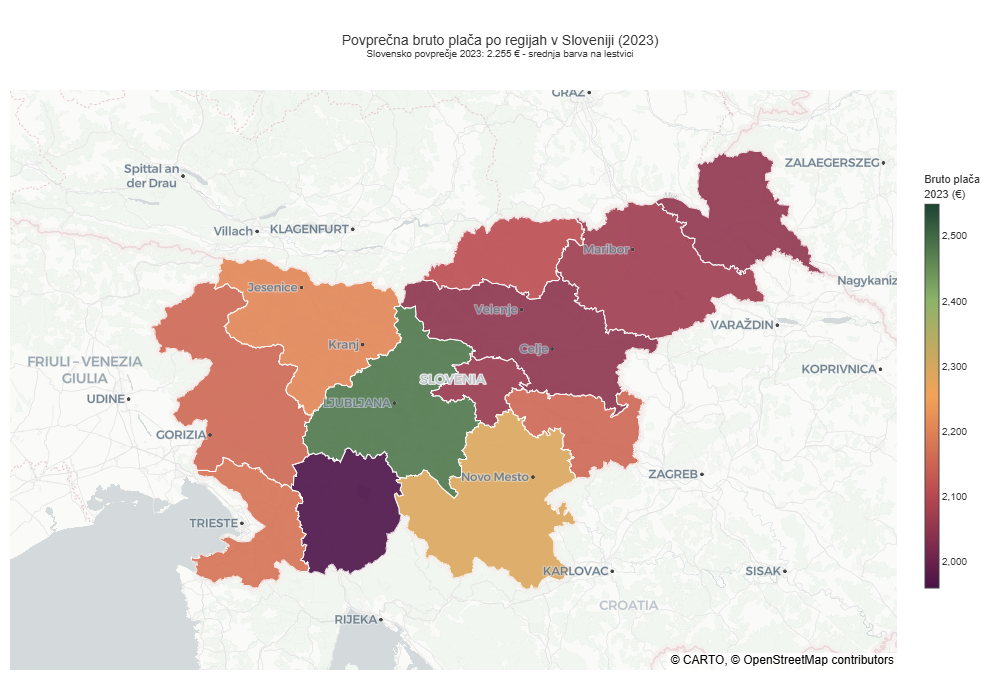

In [4]:
GEOJSON_URL = 'https://raw.githubusercontent.com/stefanb/gurs-rpe/master/data/SR.geojson'
with urllib.request.urlopen(GEOJSON_URL) as resp:
    geojson_sr = json.loads(resp.read())

for feat in geojson_sr['features']:
    feat['id'] = feat['properties']['SR_UIME']

df_map = df[~df["regija"].isin(exclude)].copy()
df_map['bruto_2023'] = pd.to_numeric(df_map['bruto_2023'], errors='coerce')

geo_ids = {f['id'] for f in geojson_sr['features']}
matched = df_map['regija'].isin(geo_ids).sum()
print(f"Ujemanje: {matched}/{len(df_map)} regij")

fig = go.Figure(go.Choroplethmap(
    geojson=geojson_sr,
    locations=df_map['regija'],
    z=df_map['bruto_2023'],
    customdata=df_map[['regija', 'bruto_2023']].values,
    hovertemplate=(
        '<b>%{customdata[0]}</b><br>'
        'Bruto plača 2023: %{customdata[1]:,.0f} €'
        '<extra></extra>'
    ),
    colorscale=[
        [0.00, '#4B1248'],
        [0.25, '#BC4B51'],
        [0.50, '#F4A259'],
        [0.75, '#8CB369'],
        [1.00, '#1B4332'],
    ],
    zmid=SLO_BRUTO[2023],
    colorbar=dict(
        title=dict(text='Bruto plača<br>2023 (€)', font=dict(size=11, color='#333333')),
        tickfont=dict(size=10, color='#333333'),
        tickformat=',.0f',
        len=0.75,
        thickness=14,
    ),
    marker_line_color='white',
    marker_line_width=1.0,
    marker_opacity=0.9,
))

fig.update_layout(
    title=dict(
        text=(
            'Povprečna bruto plača po regijah v Sloveniji (2023)<br>'
            '<sup>Slovensko povprečje 2023: 2.255 € - srednja barva na lestvici</sup>'
        ),
        font=dict(size=14, color='#333333'),
        x=0.5, xanchor='center',
    ),
    map=dict(
        style='carto-positron',
        center=dict(lat=46.12, lon=14.82),
        zoom=7.2,
    ),
    paper_bgcolor='white',
    font=dict(family='Arial, sans-serif', size=12, color='#333333'),
    margin=dict(l=10, r=10, t=90, b=10),
    width=1000,
    height=680,
)

pio.renderers.default = 'png'
fig.show()